# Import Library & Upload Dataset Bersih

In [ ]:
import pandas as pd
import re
from google.colab import files

print("Silakan upload file dataset hasil pembersihan (ulasan_plnmobile_clean.csv)")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, encoding="utf-8")

print("Dataset berhasil dimuat")
print(f"Jumlah data: {len(df)}")

df.head(10)

Silakan upload file dataset hasil pembersihan (ulasan_plnmobile_clean.csv)


Saving ulasan_plnmobile_clean.csv to ulasan_plnmobile_clean.csv
Dataset berhasil dimuat
Jumlah data: 16246


,nama,rating,ulasan,tanggal,sumber
0,kus wanto,5.0,aplikasi yg sangat bermanfaat utk urusan kelis...,2025-09-26 00:05:57,ulasan_plnmobile_googleplaystore.csv
1,askhar muda,5.0,sangat membantu proses pengaduan,2025-09-26 00:08:49,ulasan_plnmobile_googleplaystore.csv
2,Heru Cahyono,5.0,Lebih mudah dan cepat tanggap,2025-09-26 00:09:27,ulasan_plnmobile_googleplaystore.csv
3,Venitri Kudji Ratu,5.0,hadirnya aplikasi ini sangat guna ketika ada g...,2025-09-26 00:14:52,ulasan_plnmobile_googleplaystore.csv
4,Felix __,5.0,laporan langsung ke pln pakai pln mobile..muda...,2025-09-26 00:25:25,ulasan_plnmobile_googleplaystore.csv
5,Baso Itung,5.0,sangat membantu pelanggan,2025-09-26 00:39:53,ulasan_plnmobile_googleplaystore.csv
6,Omteddy Teddy,5.0,mudah dan terpercaya,2025-09-26 00:44:09,ulasan_plnmobile_googleplaystore.csv
7,Misra Misra,5.0,semenjak ad aplikasi PLN mobile saya sngat mud...,2025-09-26 00:44:36,ulasan_plnmobile_googleplaystore.csv
8,Rosna Kolo,5.0,pln terbaik dengan aplikasi PLN mobile mantap,2025-09-26 00:44:57,ulasan_plnmobile_googleplaystore.csv
9,izi muhsin,5.0,tingkatkan pelayanan di ulp,2025-09-26 00:46:33,ulasan_plnmobile_googleplaystore.csv


# Install Wordcloud dan Fungsi WordCloud (Reusable)

In [ ]:
!pip install wordcloud
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [ ]:
def show_wordcloud(text_series, title):
    text = " ".join(text_series.dropna().astype(str))

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.show()

# Wordcloud Data Awal

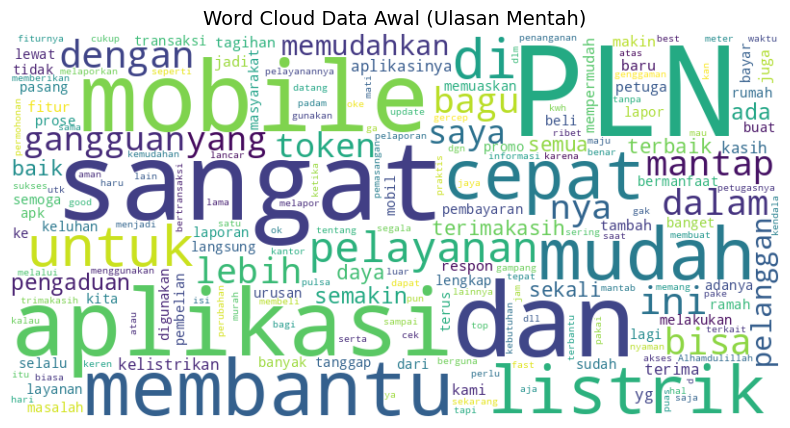

In [ ]:
show_wordcloud(df['ulasan'], "Word Cloud Data Awal (Ulasan Mentah)")

# Text Cleaning

In [ ]:
def text_cleaning(text):
    text = str(text)

    # Menghapus URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # Menghapus mention (@username) dan hashtag
    text = re.sub(r"@\w+|#\w+", "", text)

    # Menghapus emoji dan simbol non-latin
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    # Menghapus angka
    text = re.sub(r"\d+", " ", text)

    # Menghapus tanda baca dan simbol
    text = re.sub(r"[^\w\s]", " ", text)

    # Menghapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['cleaned_text'] = df['ulasan'].apply(text_cleaning)

df[['ulasan', 'cleaned_text']].head(10)

,ulasan,cleaned_text
0,aplikasi yg sangat bermanfaat utk urusan kelis...,aplikasi yg sangat bermanfaat utk urusan kelis...
1,sangat membantu proses pengaduan,sangat membantu proses pengaduan
2,Lebih mudah dan cepat tanggap,Lebih mudah dan cepat tanggap
3,hadirnya aplikasi ini sangat guna ketika ada g...,hadirnya aplikasi ini sangat guna ketika ada g...
4,laporan langsung ke pln pakai pln mobile..muda...,laporan langsung ke pln pakai pln mobile mudah...
5,sangat membantu pelanggan,sangat membantu pelanggan
6,mudah dan terpercaya,mudah dan terpercaya
7,semenjak ad aplikasi PLN mobile saya sngat mud...,semenjak ad aplikasi PLN mobile saya sngat mud...
8,pln terbaik dengan aplikasi PLN mobile mantap,pln terbaik dengan aplikasi PLN mobile mantap
9,tingkatkan pelayanan di ulp,tingkatkan pelayanan di ulp


# Word Cloud Text Cleaning

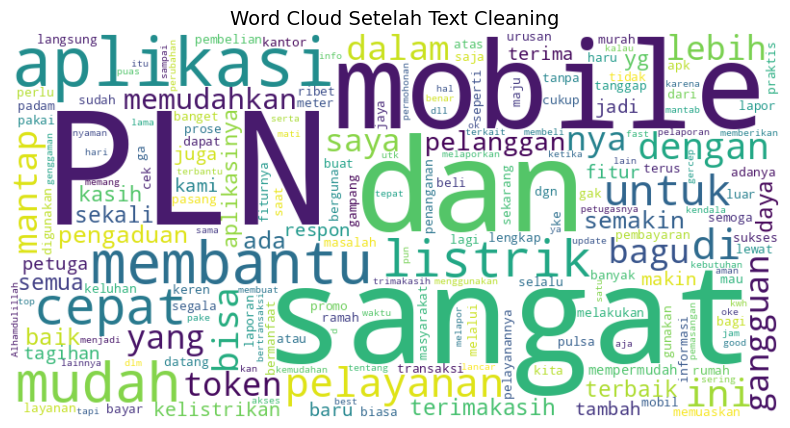

In [ ]:
show_wordcloud(df['cleaned_text'], "Word Cloud Setelah Text Cleaning")

#  Case Folding

In [ ]:
# Mengubah seluruh teks menjadi huruf kecil
df['casefold_text'] = df['cleaned_text'].str.lower()

# Menampilkan hasil setelah case folding
df[['cleaned_text', 'casefold_text']].head(10)

,cleaned_text,casefold_text
0,aplikasi yg sangat bermanfaat utk urusan kelis...,aplikasi yg sangat bermanfaat utk urusan kelis...
1,sangat membantu proses pengaduan,sangat membantu proses pengaduan
2,Lebih mudah dan cepat tanggap,lebih mudah dan cepat tanggap
3,hadirnya aplikasi ini sangat guna ketika ada g...,hadirnya aplikasi ini sangat guna ketika ada g...
4,laporan langsung ke pln pakai pln mobile mudah...,laporan langsung ke pln pakai pln mobile mudah...
5,sangat membantu pelanggan,sangat membantu pelanggan
6,mudah dan terpercaya,mudah dan terpercaya
7,semenjak ad aplikasi PLN mobile saya sngat mud...,semenjak ad aplikasi pln mobile saya sngat mud...
8,pln terbaik dengan aplikasi PLN mobile mantap,pln terbaik dengan aplikasi pln mobile mantap
9,tingkatkan pelayanan di ulp,tingkatkan pelayanan di ulp


# Word Cloud Case Folding

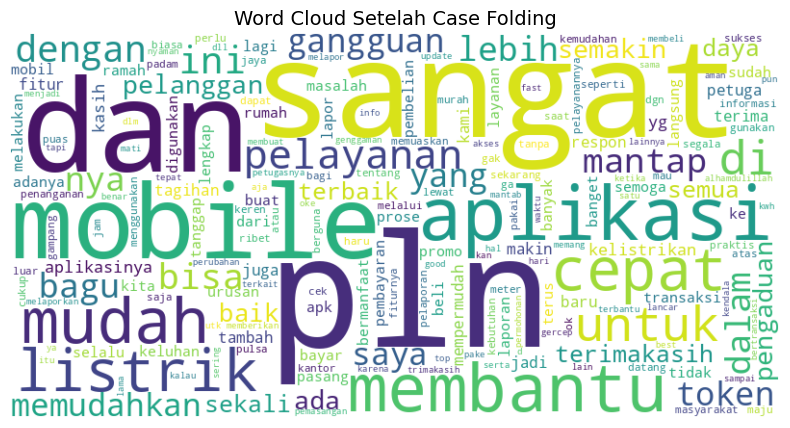

In [ ]:
show_wordcloud(df['casefold_text'], "Word Cloud Setelah Case Folding")

# Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Mengunduh resource tokenizer NLTK (punkt)
nltk.download('punkt_tab')

# Melakukan tokenisasi (memecah hasil case folding menjadi token)
df['tokenized_text'] = df['casefold_text'].apply(word_tokenize)

# Menampilkan 10 data pertama untuk melihat hasil tokenisasi
df[['casefold_text', 'tokenized_text']].head(10)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,casefold_text,tokenized_text
0,aplikasi yg sangat bermanfaat utk urusan kelis...,"[aplikasi, yg, sangat, bermanfaat, utk, urusan..."
1,sangat membantu proses pengaduan,"[sangat, membantu, proses, pengaduan]"
2,lebih mudah dan cepat tanggap,"[lebih, mudah, dan, cepat, tanggap]"
3,hadirnya aplikasi ini sangat guna ketika ada g...,"[hadirnya, aplikasi, ini, sangat, guna, ketika..."
4,laporan langsung ke pln pakai pln mobile mudah...,"[laporan, langsung, ke, pln, pakai, pln, mobil..."
5,sangat membantu pelanggan,"[sangat, membantu, pelanggan]"
6,mudah dan terpercaya,"[mudah, dan, terpercaya]"
7,semenjak ad aplikasi pln mobile saya sngat mud...,"[semenjak, ad, aplikasi, pln, mobile, saya, sn..."
8,pln terbaik dengan aplikasi pln mobile mantap,"[pln, terbaik, dengan, aplikasi, pln, mobile, ..."
9,tingkatkan pelayanan di ulp,"[tingkatkan, pelayanan, di, ulp]"


# Word Cloud Tokenization

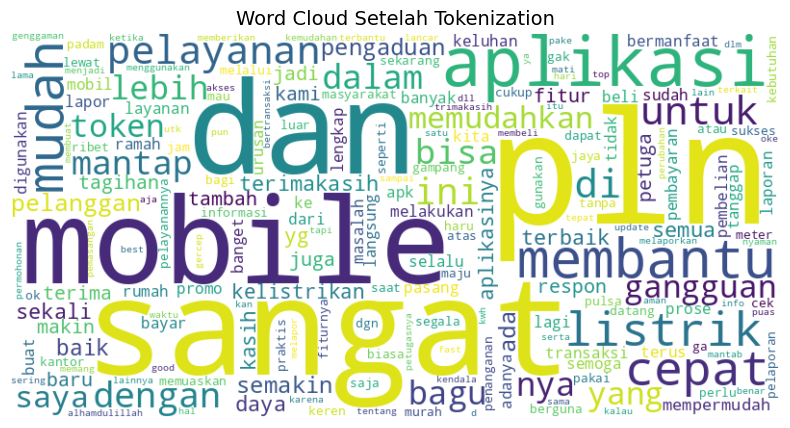

In [ ]:
df['token_text'] = df['tokenized_text'].apply(lambda x: " ".join(x))
show_wordcloud(df['token_text'], "Word Cloud Setelah Tokenization")

# Normalization

In [ ]:
import pandas as pd

# URL kamusalay (kamus kata tidak baku → kata baku Bahasa Indonesia)
kamusalay_url = "https://raw.githubusercontent.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/master/new_kamusalay.csv"

# Membaca file kamusalay langsung dari GitHub
kamusalay = pd.read_csv(
    kamusalay_url,
    encoding="latin-1",
    header=None
)
kamusalay.columns = ['slang', 'formal']
kamusalay.head()

# Membuat dictionary dari kamusalay
slang_dict = dict(zip(kamusalay['slang'], kamusalay['formal']))
len(slang_dict)

# Daftar kata yang tidak boleh dinormalisasi
exception_words = {'pln', 'wib'}

# Fungsi normalisasi teks
def normalize_text(tokens):
    normalized_tokens = []
    for word in tokens:
        # Jika kata termasuk pengecualian, biarkan apa adanya
        if word in exception_words:
            normalized_tokens.append(word)
        else:
            normalized_tokens.append(slang_dict.get(word, word))
    return normalized_tokens

# Menerapkan normalisasi pada hasil tokenisasi
df['normalized_text'] = df['tokenized_text'].apply(normalize_text)

# Menampilkan hasil tokenisasi dan normalisasi
df[['tokenized_text', 'normalized_text']].head(10)


,tokenized_text,normalized_text
0,"[aplikasi, yg, sangat, bermanfaat, utk, urusan...","[aplikasi, yang, sangat, bermanfaat, untuk, ur..."
1,"[sangat, membantu, proses, pengaduan]","[sangat, membantu, proses, pengaduan]"
2,"[lebih, mudah, dan, cepat, tanggap]","[lebih, mudah, dan, cepat, tanggap]"
3,"[hadirnya, aplikasi, ini, sangat, guna, ketika...","[hadirnya, aplikasi, ini, sangat, guna, ketika..."
4,"[laporan, langsung, ke, pln, pakai, pln, mobil...","[laporan, langsung, ke, pln, pakai, pln, mobil..."
5,"[sangat, membantu, pelanggan]","[sangat, membantu, pelanggan]"
6,"[mudah, dan, terpercaya]","[mudah, dan, terpercaya]"
7,"[semenjak, ad, aplikasi, pln, mobile, saya, sn...","[semenjak, ada, aplikasi, pln, mobile, saya, s..."
8,"[pln, terbaik, dengan, aplikasi, pln, mobile, ...","[pln, terbaik, dengan, aplikasi, pln, mobile, ..."
9,"[tingkatkan, pelayanan, di, ulp]","[tingkatkan, pelayanan, di, ulp]"


# Word Cloud Normalization

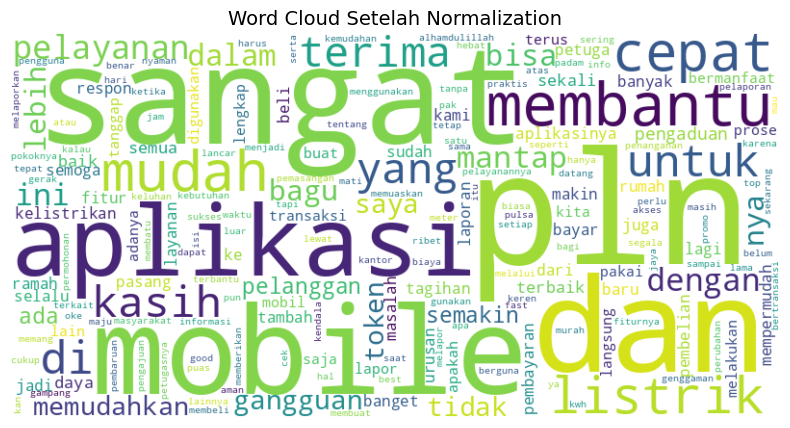

In [ ]:
df['normalized_text_str'] = df['normalized_text'].apply(lambda x: " ".join(x))
show_wordcloud(df['normalized_text_str'], "Word Cloud Setelah Normalization")

# Stopword Removal

# Stopword Removal Tahap 1

In [ ]:
# Install dan import Sastrawi
!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Ambil stopwords bawaan Sastrawi
stop_factory = StopWordRemoverFactory()
stopwords_sastrawi = set(stop_factory.get_stop_words())

# Fungsi stopword removal tahap 1
def remove_stopwords_stage1(tokens):
    return [word for word in tokens if word not in stopwords_sastrawi]

# Menerapkan stopword removal tahap 1 pada hasil normalisasi
df['stopword_stage1'] = df['normalized_text'].apply(remove_stopwords_stage1)

# Menampilkan hasil
df[['normalized_text', 'stopword_stage1']].head(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00


,normalized_text,stopword_stage1
0,"[aplikasi, yang, sangat, bermanfaat, untuk, ur...","[aplikasi, sangat, bermanfaat, urusan, kelistr..."
1,"[sangat, membantu, proses, pengaduan]","[sangat, membantu, proses, pengaduan]"
2,"[lebih, mudah, dan, cepat, tanggap]","[lebih, mudah, cepat, tanggap]"
3,"[hadirnya, aplikasi, ini, sangat, guna, ketika...","[hadirnya, aplikasi, sangat, gangguan, listrik..."
4,"[laporan, langsung, ke, pln, pakai, pln, mobil...","[laporan, langsung, pln, pakai, pln, mobile, m..."
5,"[sangat, membantu, pelanggan]","[sangat, membantu, pelanggan]"
6,"[mudah, dan, terpercaya]","[mudah, terpercaya]"
7,"[semenjak, ada, aplikasi, pln, mobile, saya, s...","[semenjak, aplikasi, pln, mobile, sangat, muda..."
8,"[pln, terbaik, dengan, aplikasi, pln, mobile, ...","[pln, terbaik, aplikasi, pln, mobile, mantap]"
9,"[tingkatkan, pelayanan, di, ulp]","[tingkatkan, pelayanan, ulp]"


# Analisis Frekuensi Kata (yang paling banyak muncul)

In [ ]:
from collections import Counter

# Menggabungkan seluruh token
all_words = [word for tokens in df['stopword_stage1'] for word in tokens]

# Menghitung frekuensi
word_freq = Counter(all_words)

# Mengambil 150 kata paling sering
top_150_words = word_freq.most_common(150)

# Tampilkan 150 kata paling sering
top_150_words

[('pln', 9174),
 ('sangat', 6759),
 ('mobile', 5267),
 ('aplikasi', 5132),
 ('membantu', 4042),
 ('mudah', 3575),
 ('cepat', 3197),
 ('listrik', 2952),
 ('pelayanan', 1947),
 ('mantap', 1636),
 ('nya', 1375),
 ('bagus', 1370),
 ('lebih', 1347),
 ('terima kasih', 1271),
 ('gangguan', 1201),
 ('token', 1200),
 ('memudahkan', 1097),
 ('pelanggan', 1085),
 ('semakin', 1083),
 ('pengaduan', 1049),
 ('baik', 982),
 ('semua', 940),
 ('daya', 904),
 ('sekali', 899),
 ('terbaik', 893),
 ('kasih', 843),
 ('aplikasinya', 826),
 ('kelistrikan', 809),
 ('terima', 784),
 ('jadi', 774),
 ('fitur', 738),
 ('petugas', 703),
 ('tambah', 686),
 ('tagihan', 684),
 ('baru', 677),
 ('makin', 661),
 ('respon', 630),
 ('mempermudah', 626),
 ('banyak', 595),
 ('pembayaran', 571),
 ('beli', 548),
 ('ramah', 527),
 ('laporan', 519),
 ('masalah', 513),
 ('pasang', 508),
 ('semoga', 501),
 ('bayar', 488),
 ('banget', 486),
 ('layanan', 476),
 ('pembelian', 466),
 ('selalu', 456),
 ('urusan', 445),
 ('rumah', 431),

# Sopword Removal Tahap Kedua

In [ ]:
# Kustomisasi daftar stopword
custom_stopwords = {'nya', 'banget', 'sekali', 'pokoknya', 'aja', 'kok', 'sih', 'dong', 'lah', 'kan', 'mantap', 'oke',
                    'hebat', 'best', 'good', 'sekarang', 'hari', 'waktu', 'semua', 'banyak', 'lebih', 'selalu', 'jadi', 'bintang',
                    'lainnya', 'segala', 'cukup', 'biasa', 'alhamdulillah', 'the', 'fast', 'pak', 'terima kasih', 'terima', 'kasih',
                    'trimakasih', 'terimakasih', 'mobil', 'sangat', 'kalau', 'memang','bojonggede', 'luar', 'seluruh', 'indonesia', 'mobil makin', 'batu'}
# Menggabungkan stopwords
final_stopwords = stopwords_sastrawi.union(custom_stopwords)

# Fungsi stopword removal tahap 2
def remove_stopwords_stage2(tokens):
    return [word for word in tokens if word not in final_stopwords]

# Menerapkan stopword removal tahap 2
df['stopword_removed'] = df['stopword_stage1'].apply(remove_stopwords_stage2)

# Menampilkan hasil
df[['stopword_stage1', 'stopword_removed']].head(10)


,stopword_stage1,stopword_removed
0,"[aplikasi, sangat, bermanfaat, urusan, kelistr...","[aplikasi, bermanfaat, urusan, kelistrikan]"
1,"[sangat, membantu, proses, pengaduan]","[membantu, proses, pengaduan]"
2,"[lebih, mudah, cepat, tanggap]","[mudah, cepat, tanggap]"
3,"[hadirnya, aplikasi, sangat, gangguan, listrik...","[hadirnya, aplikasi, gangguan, listrik, rumah]"
4,"[laporan, langsung, pln, pakai, pln, mobile, m...","[laporan, langsung, pln, pakai, pln, mobile, m..."
5,"[sangat, membantu, pelanggan]","[membantu, pelanggan]"
6,"[mudah, terpercaya]","[mudah, terpercaya]"
7,"[semenjak, aplikasi, pln, mobile, sangat, muda...","[semenjak, aplikasi, pln, mobile, mudah, melak..."
8,"[pln, terbaik, aplikasi, pln, mobile, mantap]","[pln, terbaik, aplikasi, pln, mobile]"
9,"[tingkatkan, pelayanan, ulp]","[tingkatkan, pelayanan, ulp]"


# Word Cloud Stopword Removal

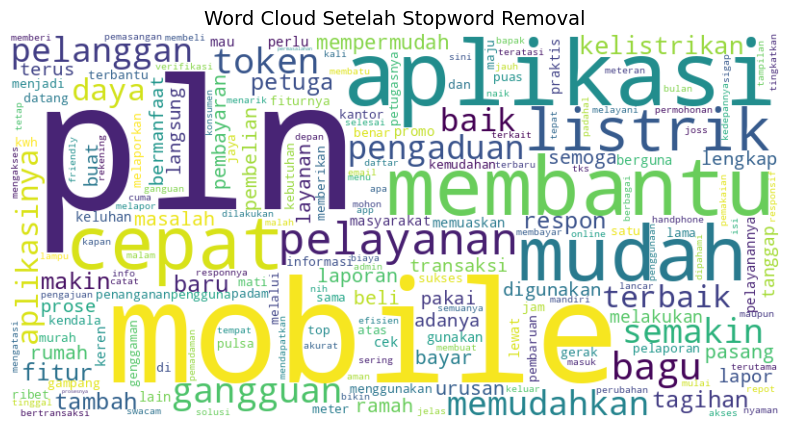

In [ ]:
df['stopword_text'] = df['stopword_removed'].apply(lambda x: " ".join(x))
show_wordcloud(df['stopword_text'], "Word Cloud Setelah Stopword Removal")

# Stemming

In [ ]:
# Mengubah kata menjadi kata dasar menggunakan Sastrawi Stemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Membuat objek stemmer
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# Fungsi stemming
def stemming_text(tokens):
    return [stemmer.stem(word) for word in tokens]

# Menerapkan stemming pada hasil stopword removal
df['stemmed_text'] = df['stopword_removed'].apply(stemming_text)

# Menampilkan hasil
df[['stopword_removed', 'stemmed_text']].head(10)

,stopword_removed,stemmed_text
0,"[aplikasi, bermanfaat, urusan, kelistrikan]","[aplikasi, manfaat, urus, listrik]"
1,"[membantu, proses, pengaduan]","[bantu, proses, adu]"
2,"[mudah, cepat, tanggap]","[mudah, cepat, tanggap]"
3,"[hadirnya, aplikasi, gangguan, listrik, rumah]","[hadir, aplikasi, ganggu, listrik, rumah]"
4,"[laporan, langsung, pln, pakai, pln, mobile, m...","[lapor, langsung, pln, pakai, pln, mobile, mud..."
5,"[membantu, pelanggan]","[bantu, langgan]"
6,"[mudah, terpercaya]","[mudah, percaya]"
7,"[semenjak, aplikasi, pln, mobile, mudah, melak...","[semenjak, aplikasi, pln, mobile, mudah, laku,..."
8,"[pln, terbaik, aplikasi, pln, mobile]","[pln, baik, aplikasi, pln, mobile]"
9,"[tingkatkan, pelayanan, ulp]","[tingkat, layan, ulp]"


# Word Cloud Stemming

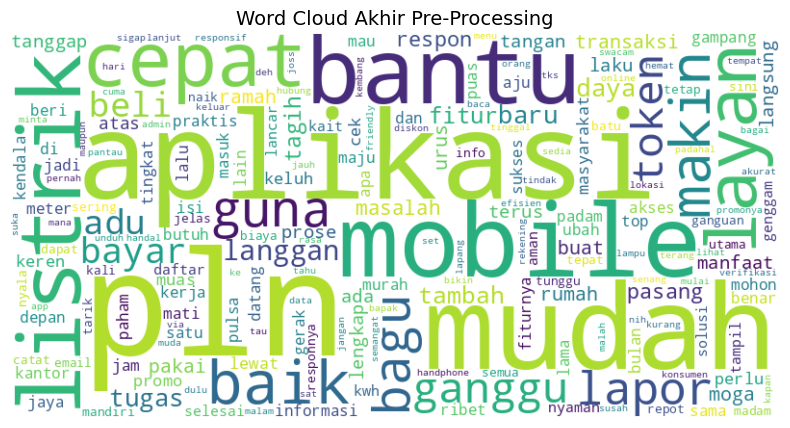

In [ ]:
df['stemmed_text_str'] = df['stemmed_text'].apply(lambda x: " ".join(x))
show_wordcloud(df['stemmed_text_str'], "Word Cloud Akhir Pre-Processing")

# Menyatukan Hasil

In [ ]:
# Menggabungkan token menjadi teks akhir
df['final_text'] = df['stemmed_text'].apply(lambda x: " ".join(x))

# Memilih kolom akhir
df_final = df[['nama', 'rating', 'final_text', 'tanggal', 'sumber']]

# Mengecek Missing Values

In [ ]:
# Daftar kolom yang akan dicek
columns_to_check = [
    'ulasan',
    'cleaned_text',
    'casefold_text',
    'tokenized_text',
    'normalized_text',
    'stopword_removed',
    'stemmed_text',
    'final_text'
]

# Menghitung jumlah missing values
missing_values = df[columns_to_check].isnull().sum()

# Menampilkan dalam bentuk tabel
missing_values_df = missing_values.reset_index()
missing_values_df.columns = ['Tahapan Pre-processing', 'Jumlah Missing Values']

missing_values_df



,Tahapan Pre-processing,Jumlah Missing Values
0,ulasan,0
1,cleaned_text,0
2,casefold_text,0
3,tokenized_text,0
4,normalized_text,0
5,stopword_removed,0
6,stemmed_text,0
7,final_text,0


In [ ]:
# Menghapus baris yang memiliki missing values
df = df.dropna(subset=columns_to_check)

print("Jumlah data setelah eliminasi:", len(df))

Jumlah data setelah eliminasi: 16246


# Menyimpan Dataset

In [ ]:
# Menyimpan ke CSV
output_file = "ulasan_plnmobile_preprocessing.csv"
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("Text Pre-processing selesai")
print(f"Jumlah data akhir: {len(df_final)}")
print(f"File disimpan sebagai: {output_file}")

files.download(output_file)

Text Pre-processing selesai
Jumlah data akhir: 16246
File disimpan sebagai: ulasan_plnmobile_preprocessing.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>